# Large-Scale GP with SKI

Structured Kernel Interpolation (KISS-GP) turns matrix-vector products against
the kernel matrix into **FFTs**, dropping the cost from O(N²) to O(N log N) per
matvec. On Apple Silicon LightGP uses Accelerate's vDSP DFT; on NVIDIA it uses
cuFFT.

Restrictions:

- Only practical for **D ≤ 3** (the grid size explodes in higher dimensions)
- Approximation quality depends on grid density
- Best for stationary, well-conditioned kernels (RBF / Matérn on smooth data)

In [1]:
import os
import sys

# Make the locally-built lightgp importable. Real users install via 'pip install lightgp'.
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..", "python")))

import numpy as np
import matplotlib.pyplot as plt
import lightgp as gp

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (8, 3.5), "figure.dpi": 90})

## Fit 50,000 points

`Solver.SKI` + `Backend.CPU` selects the vDSP path on macOS.

In [2]:
import time

N = 50_000
X = np.linspace(-10, 10, N, dtype=np.float32).reshape(-1, 1)
y = (np.sin(X[:, 0]) + 0.15 * rng.standard_normal(N)).astype(np.float32)

model = gp.GPExact(gp.RBF(), solver=gp.Solver.SKI, backend=gp.Backend.CPU, noise_var=0.05)
t0 = time.perf_counter()
model.fit(X, y)
fit_ms = (time.perf_counter() - t0) * 1000.0
print(f"SKI fit at N={N}: {fit_ms:.1f} ms")

SKI fit at N=50000: 374.3 ms


## Predict and plot a slice

SKI predict at M_test=600: 12556.3 ms


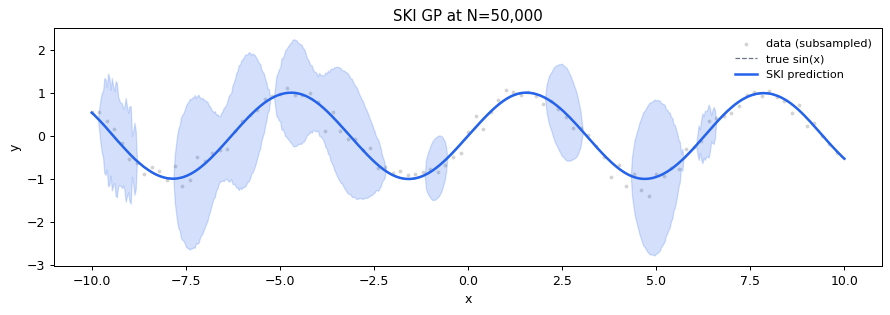

In [3]:
X_test = np.linspace(-10, 10, 600).reshape(-1, 1).astype(np.float32)
t0 = time.perf_counter()
pred = model.predict(X_test)
pred_ms = (time.perf_counter() - t0) * 1000.0
print(f"SKI predict at M_test={len(X_test)}: {pred_ms:.1f} ms")

mu, sd = pred["mean"], np.sqrt(np.maximum(pred["var"], 0))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.scatter(X[::500, 0], y[::500], c="lightgray", s=4, label="data (subsampled)")
ax.plot(X_test[:, 0], np.sin(X_test[:, 0]), color="#6B7280", ls="--", lw=1, label="true sin(x)")
ax.fill_between(X_test[:, 0], mu - 2*sd, mu + 2*sd, alpha=0.2, color="#2563EB")
ax.plot(X_test[:, 0], mu, lw=2, color="#2563EB", label="SKI prediction")
ax.legend(fontsize=9, frameon=False); ax.set_title(f"SKI GP at N={N:,}")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## How SKI works (one-paragraph intuition)

1. Project the data onto a regular grid via a sparse cubic-interpolation matrix W: `K ≈ W K_grid W^T`
2. The grid kernel `K_grid` is Toeplitz (1D) or Kronecker-Toeplitz (2D / 3D)
3. Toeplitz matrix-vector products are FFTs in O(M log M)
4. Conjugate gradients with this fast matvec solves the GP equations without ever forming K

The cost shifts from `O(N²)` per matvec to `O(N + M log M)`.

## Decision flowchart

```text
N < 5,000?                          → Solver.Cholesky (exact, simple)
5k ≤ N < 50k, any D?                → Solver.CG (matrix-free on GPU)
N > 50k, D ≤ 3?                     → Solver.SKI  ← you are here
N > 50k, D > 3?                     → GPSparse (inducing-point)
```

The next tutorial covers how to control the compute backend (CPU / Metal / CUDA).